# FRL submission — main-paper exhibits (Figure 1, Table 1)

Rebuilds the current FRL manuscript's Figure 1 and Table 1 from the aggregate artifacts, and asserts every printed number at its displayed rounding.
Formatting: log points and probabilities to 4 dp; explicit n throughout. No licensed microdata.


## Setup


In [ ]:
import json, os
import pandas as pd
pd.set_option("display.width", 200); pd.set_option("display.max_colwidth", 90)
ART = "../artifacts"
def A(name):
    with open(os.path.join(ART, name + ".json"), encoding="utf-8") as f: return json.load(f)
def show(df, t): print(t); print("-" * len(t)); print(df.to_string(index=False)); print()
def f4(x): return f"{x:+.4f}"
def ci4(c): return f"[{c[0]:+.4f}, {c[1]:+.4f}]"
def okp(a, b, nd=4): assert round(a, nd) == round(b, nd), (a, b)
print("ready")


ready


## Figure 1 — mean gap and severe-contraction excess across event clocks


Figure 1 rebuilt; manuscript values asserted (mean path, event tail 0.1099 [0.0907, 0.1291]).


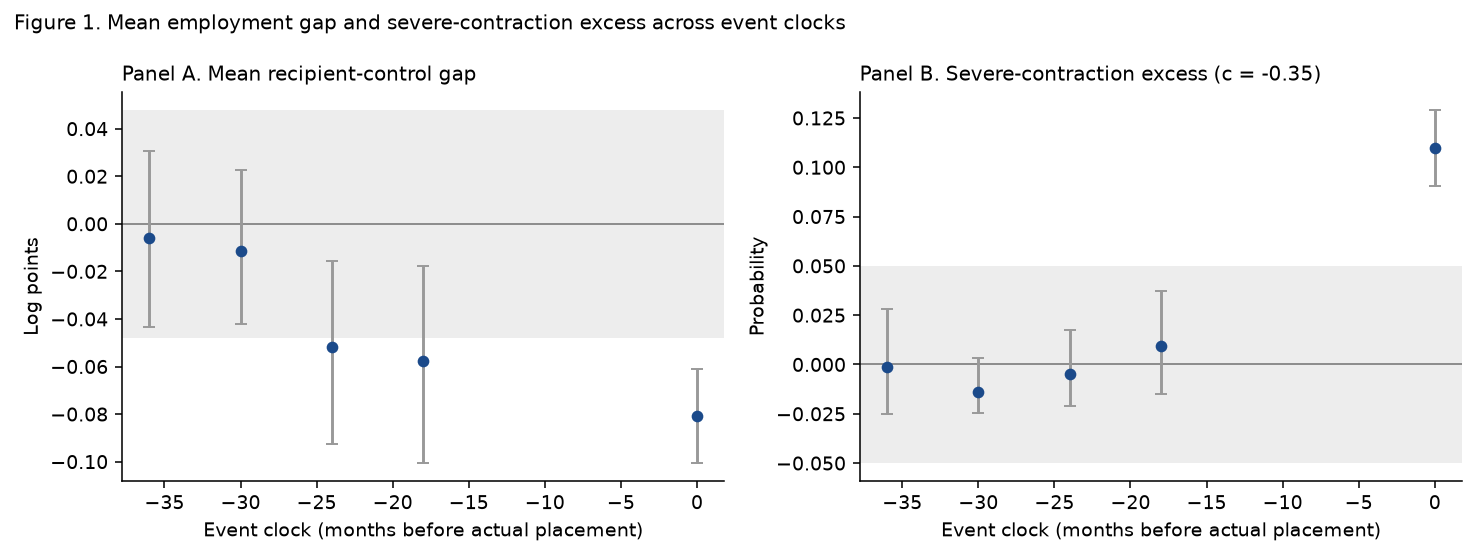

In [ ]:
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
fg = A("wp11fg"); g = fg["g_placebo_grid"]; fh = fg["f_honest"]
clocks = ["t-36", "t-30", "t-24", "t-18"]; xs = [-36, -30, -24, -18, 0]
mean_b = [g[c]["mean"] for c in clocks] + [fh["mean"]["effect"]]
mean_ci = [g[c]["mean_ci"] for c in clocks] + [fh["mean"]["grid"][0]["ci"]]
tail_b = [g[c]["tail"] for c in clocks] + [fh["tail"]["effect"]]
tail_ci = [g[c]["tail_ci"] for c in clocks] + [fh["tail"]["grid"][0]["ci"]]
# 원고 수치 대조 (Figure 1 / Table B2)
okp(mean_b[0], -0.0058); okp(mean_b[2], -0.0520); okp(mean_b[4], -0.0809)
okp(tail_b[4], 0.1099); okp(tail_ci[4][0], 0.0907); okp(tail_ci[4][1], 0.1291)
fig, ax = plt.subplots(1, 2, figsize=(10.6, 4.0))
for a, b, ci, band, ttl, ylab in ((ax[0], mean_b, mean_ci, fg["delta_mean"], "Panel A. Mean recipient-control gap", "Log points"),
                                  (ax[1], tail_b, tail_ci, 0.05, "Panel B. Severe-contraction excess (c = -0.35)", "Probability")):
    import numpy as np
    b = np.array(b); lo = np.array([c[0] for c in ci]); hi = np.array([c[1] for c in ci])
    a.axhspan(-band, band, color="0.55", alpha=.15, lw=0)
    a.axhline(0, color="0.45", lw=.8)
    a.errorbar(xs, b, yerr=[b - lo, hi - b], fmt="o", ms=5, capsize=3, color="#1b4a8a", ecolor="0.6")
    a.set_title(ttl, fontsize=10.5, loc="left"); a.set_xlabel("Event clock (months before actual placement)"); a.set_ylabel(ylab)
    a.spines[["top", "right"]].set_visible(False)
fig.suptitle("Figure 1. Mean employment gap and severe-contraction excess across event clocks", x=.01, ha="left", fontsize=10.5)
fig.tight_layout()
print("Figure 1 rebuilt; manuscript values asserted (mean path, event tail 0.1099 [0.0907, 0.1291]).")


## Table 1, Panel A — actual event vs pooled pseudo-events


In [ ]:
r = A("wp13c_pooled_placebo")["runs"]
p = r["A_pooled_cluster"]; c = r["C_common_pooled_cluster"]
rows = [{"Statistic": s.capitalize() if s != "p10" else "Tenth percentile",
         "Event - pooled pseudo": f4(p[s]["obs"]), "95% CI": ci4(p[s]["ci"]),
         "Common 116-firm sample": f4(c[s]["obs"]), "CI ": ci4(c[s]["ci"])}
        for s in ("mean", "p10", "p25", "median")]
show(pd.DataFrame(rows), "Table 1, Panel A. Actual event versus pooled pseudo-events (and Appendix Table B3)")
okp(p["mean"]["obs"], -0.0481); okp(p["p10"]["obs"], -0.2527); okp(p["p25"]["obs"], -0.0641); okp(p["median"]["obs"], -0.0036)
okp(p["p10"]["ci"][0], -0.3713); okp(p["p10"]["ci"][1], -0.0953); okp(c["p10"]["obs"], -0.2193)
print(f"n: event {p['n_event']} · pooled pseudo {p['n_placebo']} (firms {p['n_placebo_firms']}) · common firms {r['C_common_n_firms']}")
print("manuscript values asserted (Table 1 Panel A, Table B3)")


Table 1, Panel A. Actual event versus pooled pseudo-events (and Appendix Table B3)
----------------------------------------------------------------------------------
       Statistic Event - pooled pseudo             95% CI Common 116-firm sample                CI 
            Mean               -0.0481 [-0.1026, +0.0040]                -0.0616 [-0.1261, -0.0006]
Tenth percentile               -0.2527 [-0.3713, -0.0953]                -0.2193 [-0.4062, -0.0709]
             P25               -0.0641 [-0.1576, -0.0001]                -0.0816 [-0.2063, -0.0038]
          Median               -0.0036 [-0.0375, +0.0249]                -0.0207 [-0.0569, +0.0163]

n: event 210 · pooled pseudo 561 (firms 169) · common firms 116
manuscript values asserted (Table 1 Panel A, Table B3)


## Table 1, Panel B — recipients vs non-recipients in the same measured state


In [ ]:
b = A("wp12b")["runs"]
d1, d0, pool, allr = b["B_distress_1"], b["B_distress_0"], b["E_pool_distress"], b["A_all_vs_all"]
i35 = allr["curve"]["grid"].index(-0.35)
def sev(run):
    j = run["curve"]["grid"].index(-0.35)
    return (run["cprob_treated"]["-0.35"], run["cprob_ctrl_w"]["-0.35"], run["curve"]["diff"][j],
            run["curve"]["lo_unif"][j], run["curve"]["hi_unif"][j])
rows = []
for s, lab in (("median", "Median"), ("p10", "Tenth percentile"), ("mean", "Mean")):
    rows.append({"Statistic": lab,
                 "Distressed": f"{f4(d1[s]['obs'])} {ci4(d1[s]['ci'])}",
                 "Non-distressed": f"{f4(d0[s]['obs'])} {ci4(d0[s]['ci'])}",
                 "Pooled": f"{f4(pool[s]['obs'])} {ci4(pool[s]['ci'])}"})
t1, c1, df1, lo1, hi1 = sev(d1); t0, c0, df0, lo0, hi0 = sev(d0); ta, ca, dfa, loa, hia = sev(allr)
rows += [{"Statistic": "Pr(severe): recipients", "Distressed": f"{t1:.4f}", "Non-distressed": f"{t0:.4f}", "Pooled": f"{ta:.4f}"},
         {"Statistic": "Pr(severe): weighted non-recipients", "Distressed": f"{c1:.4f}", "Non-distressed": f"{c0:.4f}", "Pooled": f"{ca:.4f}"},
         {"Statistic": "Difference at c=-0.35 [uniform band]", "Distressed": f"{f4(df1)} [{lo1:+.4f}, {hi1:+.4f}]",
          "Non-distressed": f"{f4(df0)} [{lo0:+.4f}, {hi0:+.4f}]", "Pooled": f"{f4(dfa)} [{loa:+.4f}, {hia:+.4f}]"}]
show(pd.DataFrame(rows), "Table 1, Panel B / Appendix Tables C3-C4. Same measured state")
okp(d1["median"]["obs"], -0.0015); okp(d1["p10"]["obs"], -0.3414); okp(d0["p10"]["obs"], -0.2197)
okp(pool["median"]["obs"], 0.0076); okp(pool["p10"]["obs"], -0.2863)
assert round(t1, 4) == 0.1826 and round(c1, 4) == 0.0442
assert round(dfa, 4) == 0.1093 and round(loa, 4) == 0.0482 and round(hia, 4) == 0.1704
print(f"n: distressed {d1['n_treated']}/{d1['n_ctrl_events']:,} events ({d1['n_ctrl_firms']} firms) · "
      f"non-distressed {d0['n_treated']}/{d0['n_ctrl_events']:,} ({d0['n_ctrl_firms']})")
print("manuscript values asserted (medians, tenth percentiles, severe rows)")


Table 1, Panel B / Appendix Tables C3-C4. Same measured state
-------------------------------------------------------------
                           Statistic                 Distressed             Non-distressed                     Pooled
                              Median -0.0015 [-0.0356, +0.0688] +0.0186 [-0.0277, +0.0393] +0.0076 [-0.0262, +0.0414]
                    Tenth percentile -0.3414 [-0.4959, -0.1682] -0.2197 [-0.3271, -0.0542] -0.2863 [-0.4054, -0.1673]
                                Mean -0.0903 [-0.1675, -0.0122] -0.0569 [-0.1065, -0.0094] -0.0752 [-0.1235, -0.0269]
              Pr(severe): recipients                     0.1826                     0.0947                     0.1429
 Pr(severe): weighted non-recipients                     0.0442                     0.0193                     0.0336
Difference at c=-0.35 [uniform band] +0.1384 [+0.0479, +0.2289] +0.0754 [-0.0009, +0.1517] +0.1093 [+0.0482, +0.1704]

n: distressed 115/27,423 events (881 firms) · non

## Prose consistency checks (§1-§3)


In [ ]:
# 본문 프로즈 수치 대조 (§1, §3.1-3.3)
fg = A("wp11fg"); g = fg["g_placebo_grid"]
okp(g["t-30"]["mean"], -0.0115); okp(g["t-18"]["mean"], -0.0576)
st = A("wp10ab")["A_stake"]
okp(st["median"], 0.0616, 4); assert st["n_stake"] == 201 and round(st["ge50"], 3) == 0.005
print("§1: stakes median 6.16%, n=201, >=50% share 0.5%  ✓")
print("§3.1: mean path -0.0058 / -0.0115 / -0.0520 / -0.0576 / -0.0809  ✓")
b6 = A("wp11o_confound")["employment"]
assert b6["all"]["n"] == 210 and b6["clean_narrow"]["n"] == 183 and b6["clean_broad"]["n"] == 157
print("§2/B.7: screens 210/183/157  ✓")
print("all prose checks passed")


§1: stakes median 6.16%, n=201, >=50% share 0.5%  ✓
§3.1: mean path -0.0058 / -0.0115 / -0.0520 / -0.0576 / -0.0809  ✓
§2/B.7: screens 210/183/157  ✓
all prose checks passed
